# Thermodynamic Analysis from Manual Loading of *SystemMetadata* Objects
*A step-by-step tutorial for processing simulation data using Ethanol-Water mixtures, using manual Metadata creation.*

In [1]:
from pathlib import Path

import numpy as np

from kbkit.schema.system_metadata import SystemMetadata
from kbkit.systems import SystemCollection, SystemProperties

In [2]:
parent_dir = Path("./test_data/ethanol_water_26C")

# check that isdir
parent_dir.is_dir()

True

In [ ]:
from natsort import natsorted

# get items in parent directory
natsorted(parent_dir.iterdir())

[PosixPath('test_data/ethanol_water_26C/.DS_Store'),
 PosixPath('test_data/ethanol_water_26C/kb_analysis'),
 PosixPath('test_data/ethanol_water_26C/sys_401'),
 PosixPath('test_data/ethanol_water_26C/sys_402'),
 PosixPath('test_data/ethanol_water_26C/sys_403'),
 PosixPath('test_data/ethanol_water_26C/sys_404'),
 PosixPath('test_data/ethanol_water_26C/sys_405'),
 PosixPath('test_data/ethanol_water_26C/sys_406'),
 PosixPath('test_data/ethanol_water_26C/sys_407'),
 PosixPath('test_data/ethanol_water_26C/sys_408'),
 PosixPath('test_data/ethanol_water_26C/sys_409'),
 PosixPath('test_data/ethanol_water_26C/sys_451')]

In [ ]:
# for a given md system, get files present
syspath = next(parent_dir.glob("*sys_403"))

natsorted(syspath.iterdir())

[PosixPath('test_data/ethanol_water_26C/sys_403/kbi_rdf_files'),
 PosixPath('test_data/ethanol_water_26C/sys_403/potential_sys_403_npt.xvg'),
 PosixPath('test_data/ethanol_water_26C/sys_403/pressure_sys_403_npt.xvg'),
 PosixPath('test_data/ethanol_water_26C/sys_403/sys_403.gro'),
 PosixPath('test_data/ethanol_water_26C/sys_403/sys_403.top'),
 PosixPath('test_data/ethanol_water_26C/sys_403/sys_403_npt.edr'),
 PosixPath('test_data/ethanol_water_26C/sys_403/temperature_sys_403_npt.xvg'),
 PosixPath('test_data/ethanol_water_26C/sys_403/volume_sys_403_npt.xvg')]

## Manual building of KBIs & KBI-derived thermodynamic properties:

1. Build *SystemCollection* object for a set of systems (each system has its own *SystemProperties* object), either via:
    
    a. From arguments that find all valid systems (i.e., like *KBPipeline* implementation) 
    
    b. Directly from a list of *SystemMetadata* object

2. Construct a *KBICalculator* class from *SystemCollection*

3. Get thermodynamic properties from *KBIs* in *PropertyResult* object and *SystemColection*

4. Make figures

### *SystemProperties*: handles molecule info and energy properties for a given MD simulation

1) Initialized by reading *.edr*, *.gro* (or *.top* if no *.gro* are present) in *system_path*


In [9]:
sysprop = SystemProperties(system_path=syspath, include="npt", start_time=10000)

sysprop.get("density"), sysprop.edr_paths, sysprop.gro_paths, sysprop.system_path

(881.46544652205,
 [PosixPath('/Users/b324115/Library/CloudStorage/Box-Box/critical_phenomena_saxs/allisons_data/pyPkgs/kbkit/examples/test_data/ethanol_water_26C/sys_403/sys_403_npt.edr')],
 [PosixPath('/Users/b324115/Library/CloudStorage/Box-Box/critical_phenomena_saxs/allisons_data/pyPkgs/kbkit/examples/test_data/ethanol_water_26C/sys_403/sys_403.gro')],
 PosixPath('/Users/b324115/Library/CloudStorage/Box-Box/critical_phenomena_saxs/allisons_data/pyPkgs/kbkit/examples/test_data/ethanol_water_26C/sys_403'))

2) Initialized from specific filepaths

In [ ]:
sysprop = SystemProperties(
    edr_path=syspath / f"{syspath.name}_npt.edr", gro_path=syspath / f"{syspath.name}.gro", start_time=10000
)
sysprop.get("density"), sysprop.edr_paths, sysprop.gro_paths, sysprop.system_path

(881.46544652205,
 [PosixPath('/Users/b324115/Library/CloudStorage/Box-Box/critical_phenomena_saxs/allisons_data/pyPkgs/kbkit/examples/test_data/ethanol_water_26C/sys_403/sys_403_npt.edr')],
 [PosixPath('/Users/b324115/Library/CloudStorage/Box-Box/critical_phenomena_saxs/allisons_data/pyPkgs/kbkit/examples/test_data/ethanol_water_26C/sys_403/sys_403.gro')],
 PosixPath('/Users/b324115/Library/CloudStorage/Box-Box/critical_phenomena_saxs/allisons_data/pyPkgs/kbkit/examples/test_data/ethanol_water_26C/sys_403'))

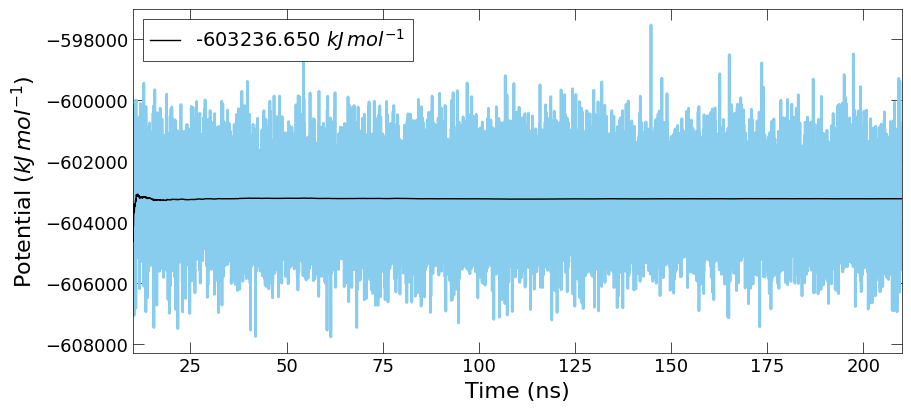

In [ ]:
# visualize md properties; check that systems have equilibrated at set start-time

sysprop.timeseries_plotter(start_time=10000).plot("potential")

### *SystemMetadata*: create metadata container for system info

In [11]:
sysmeta = SystemMetadata(
    name=sysprop.system_path.name,
    kind="mixture",  # if mixture or pure_component
    path=sysprop.system_path,
    props=sysprop,
    rdf_path=sysprop.system_path / "kbi_rdf_files",
)

In [14]:
# verify that rdf files exist in path
sysmeta.has_rdf()

True

### *SystemCollection*: building a set of systems for analysis

a.1. From loading all systems present in parent path (this is what *KBPipeline* does)

In [85]:
syscol = SystemCollection.load(
    base_path=parent_dir,  # path to mixture systems
    pure_path=Path("./test_data/pure_components"),  # path to pure component systems
    pure_systems=["ETHOL_300", "SPCEW_300"],  # pure-component systems
    start_time=10000,  # time to start for averaging energy properties
    include_mode="npt",  # string required in filename for edr/gro/top file finder if more than one files of a given type are present
    charges={},  # required for electrolyte systems: dict[str, int] mapping GROMACS molecule name to the formal charge
)

In [86]:
for meta in syscol:
    print(meta)

SystemMetadata(name='SPCEW_300', kind='pure', path=PosixPath('/Users/b324115/Library/CloudStorage/Box-Box/critical_phenomena_saxs/allisons_data/pyPkgs/kbkit/examples/test_data/pure_components/SPCEW_300'), props=<kbkit.systems.properties.SystemProperties object at 0x17a119950>, rdf_path=PosixPath('/Users/b324115/Library/CloudStorage/Box-Box/critical_phenomena_saxs/allisons_data/pyPkgs/kbkit/examples/test_data/pure_components/SPCEW_300/kbi_rdf_files'))
SystemMetadata(name='sys_409', kind='mixture', path=PosixPath('/Users/b324115/Library/CloudStorage/Box-Box/critical_phenomena_saxs/allisons_data/pyPkgs/kbkit/examples/test_data/ethanol_water_26C/sys_409'), props=<kbkit.systems.properties.SystemProperties object at 0x179c76850>, rdf_path=PosixPath('/Users/b324115/Library/CloudStorage/Box-Box/critical_phenomena_saxs/allisons_data/pyPkgs/kbkit/examples/test_data/ethanol_water_26C/sys_409/kbi_rdf_files'))
SystemMetadata(name='sys_408', kind='mixture', path=PosixPath('/Users/b324115/Library/Clo

a.2. Alternatively, the pure component simulations are not required (only for excess entropy and mixing property calculations) and for only specific systems, they can be specified

In [87]:
syscol_a = SystemCollection.load(
    base_path=parent_dir,  # path to mixture systems
    base_systems=["sys_403", "sys_405", "sys_451"],
    start_time=10000,  # time to start for averaging energy properties
    include_mode="npt",  # string required in filename for edr/gro/top file finder if more than one files of a given type are present
)

In [88]:
for meta in syscol_a:
    print(meta)

SystemMetadata(name='sys_405', kind='mixture', path=PosixPath('/Users/b324115/Library/CloudStorage/Box-Box/critical_phenomena_saxs/allisons_data/pyPkgs/kbkit/examples/test_data/ethanol_water_26C/sys_405'), props=<kbkit.systems.properties.SystemProperties object at 0x17e40a490>, rdf_path=PosixPath('/Users/b324115/Library/CloudStorage/Box-Box/critical_phenomena_saxs/allisons_data/pyPkgs/kbkit/examples/test_data/ethanol_water_26C/sys_405/kbi_rdf_files'))
SystemMetadata(name='sys_403', kind='mixture', path=PosixPath('/Users/b324115/Library/CloudStorage/Box-Box/critical_phenomena_saxs/allisons_data/pyPkgs/kbkit/examples/test_data/ethanol_water_26C/sys_403'), props=<kbkit.systems.properties.SystemProperties object at 0x17e409bd0>, rdf_path=PosixPath('/Users/b324115/Library/CloudStorage/Box-Box/critical_phenomena_saxs/allisons_data/pyPkgs/kbkit/examples/test_data/ethanol_water_26C/sys_403/kbi_rdf_files'))
SystemMetadata(name='sys_451', kind='mixture', path=PosixPath('/Users/b324115/Library/Cl

b. Manually from a list of *SystemMetadata* objects

In [89]:
systems = ["sys_403", "sys_405", "sys_451"]
sysmetas = []
for sys in systems:
    props = SystemProperties(system_path=f"{parent_dir}/{sys}", start_time=10000)
    sysmetas.append(
        SystemMetadata(
            name=sys, kind="mixture", path=props.system_path, props=props, rdf_path=props.system_path / "kbi_rdf_files"
        )
    )

sysmetas

[SystemMetadata(name='sys_403', kind='mixture', path=PosixPath('/Users/b324115/Library/CloudStorage/Box-Box/critical_phenomena_saxs/allisons_data/pyPkgs/kbkit/examples/test_data/ethanol_water_26C/sys_403'), props=<kbkit.systems.properties.SystemProperties object at 0x17e40bb10>, rdf_path=PosixPath('/Users/b324115/Library/CloudStorage/Box-Box/critical_phenomena_saxs/allisons_data/pyPkgs/kbkit/examples/test_data/ethanol_water_26C/sys_403/kbi_rdf_files')),
 SystemMetadata(name='sys_405', kind='mixture', path=PosixPath('/Users/b324115/Library/CloudStorage/Box-Box/critical_phenomena_saxs/allisons_data/pyPkgs/kbkit/examples/test_data/ethanol_water_26C/sys_405'), props=<kbkit.systems.properties.SystemProperties object at 0x17ef6c410>, rdf_path=PosixPath('/Users/b324115/Library/CloudStorage/Box-Box/critical_phenomena_saxs/allisons_data/pyPkgs/kbkit/examples/test_data/ethanol_water_26C/sys_405/kbi_rdf_files')),
 SystemMetadata(name='sys_451', kind='mixture', path=PosixPath('/Users/b324115/Libra

In [90]:
syscol_b = SystemCollection(systems=sysmetas, molecules=["ETHOL", "SPCEW"], charges={})

for meta in syscol_b:
    print(meta)

SystemMetadata(name='sys_403', kind='mixture', path=PosixPath('/Users/b324115/Library/CloudStorage/Box-Box/critical_phenomena_saxs/allisons_data/pyPkgs/kbkit/examples/test_data/ethanol_water_26C/sys_403'), props=<kbkit.systems.properties.SystemProperties object at 0x17e40bb10>, rdf_path=PosixPath('/Users/b324115/Library/CloudStorage/Box-Box/critical_phenomena_saxs/allisons_data/pyPkgs/kbkit/examples/test_data/ethanol_water_26C/sys_403/kbi_rdf_files'))
SystemMetadata(name='sys_405', kind='mixture', path=PosixPath('/Users/b324115/Library/CloudStorage/Box-Box/critical_phenomena_saxs/allisons_data/pyPkgs/kbkit/examples/test_data/ethanol_water_26C/sys_405'), props=<kbkit.systems.properties.SystemProperties object at 0x17ef6c410>, rdf_path=PosixPath('/Users/b324115/Library/CloudStorage/Box-Box/critical_phenomena_saxs/allisons_data/pyPkgs/kbkit/examples/test_data/ethanol_water_26C/sys_405/kbi_rdf_files'))
SystemMetadata(name='sys_451', kind='mixture', path=PosixPath('/Users/b324115/Library/Cl

In [91]:
syscol_a.molecules, syscol_b.molecules

(['ETHOL', 'SPCEW'], ['ETHOL', 'SPCEW'])

### *KBICalculator*: create a calculator object from *SystemCollection*

In [92]:
from kbkit.kbi import KBICalculator

calc = KBICalculator(systems=syscol, errors="warn", force=False)
calc_a = KBICalculator(systems=syscol_a, errors="warn", force=False)
calc_b = KBICalculator(systems=syscol_b, errors="warn", force=False)

*kbi()*: will calculate the KBIs for each RDF and return a a *PropertyResult* object, with attributes:
    
    - units: str, units of kbis
    
    - value: 3d matrix (shape:len(systems),len(molecules),len(molecules))

In [93]:
calc_a.kbi(units="cm^3/mol"), calc_b.kbi(units="cm^3/mol"), calc.kbi(units="cm^3/mol")

(PropertyResult(name='kbi', shape=(3, 2, 2), units='cm^3/mol'),
 PropertyResult(name='kbi', shape=(3, 2, 2), units='cm^3/mol'),
 PropertyResult(name='kbi', shape=(12, 2, 2), units='cm^3/mol'))

In [94]:
# to convert kbis to another unit

calc_b.kbi(units="nm^3/molecule").value

array([[[-0.08015003, -0.12124767],
        [-0.12124767,  0.20771933]],

       [[-0.0305767 , -0.15015291],
        [-0.15015291,  0.09500357]],

       [[-0.09366288, -0.02319421],
        [-0.02319421,  0.12450567]]])

In [95]:
calc_b.kbi(units="cm^3/mol").value

array([[[-48.26747524, -73.01705159],
        [-73.01705159, 125.09150274]],

       [[-18.41372192, -90.42419326],
        [-90.42419326,  57.21248499]],

       [[-56.40510725, -13.96788008],
        [-13.96788008,  74.97906957]]])

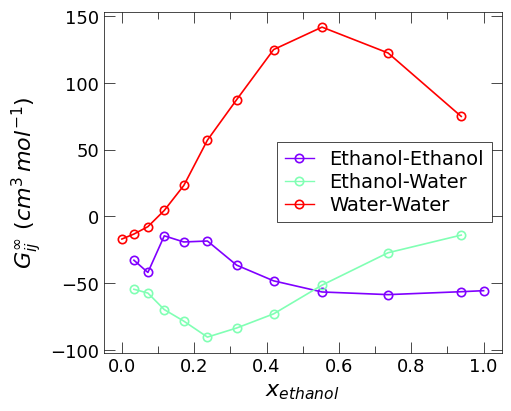

In [98]:
molmap = {"ETHOL": "Ethanol", "SPCEW": "Water"}
molecules = [molmap[mol] for mol in syscol.molecules]

eth_idx = syscol.get_mol_index("ETHOL")
eth_x = syscol.x[:, eth_idx]

calc.kbi_plotter().plot_composition(
    x=eth_x, molecules=molecules, xlab=r"$x_{ethanol}$", marker="o", ls="-", lw=1.2, mew=1.2, cmap="rainbow"
)

### *KBThermo*: Get KBI-derived thermodynamic properties

In [99]:
from kbkit.kbi import KBThermo

therm = KBThermo(systems=syscol, kbi=calc.kbi(), activity_integration_type="numerical")

In [100]:
# chemical potential derivs
therm.M()

array([[[        nan,         nan],
        [        nan,         nan]],

       [[65.39633418, -2.24947855],
        [-2.24947855,  0.07737672]],

       [[26.50898853, -2.05262333],
        [-2.05262333,  0.15893713]],

       [[11.67642957, -1.54964497],
        [-1.54964497,  0.20566214]],

       [[ 6.19178978, -1.27820703],
        [-1.27820703,  0.26386768]],

       [[ 3.22539434, -0.99888053],
        [-0.99888053,  0.30934584]],

       [[ 2.06797342, -0.96056294],
        [-0.96056294,  0.44617651]],

       [[ 1.32085702, -0.95438563],
        [-0.95438563,  0.68959162]],

       [[ 0.91784502, -1.13693728],
        [-1.13693728,  1.4083275 ]],

       [[ 0.59791105, -1.66660971],
        [-1.66660971,  4.6454869 ]],

       [[ 0.15627615, -2.3715961 ],
        [-2.3715961 , 35.9905733 ]],

       [[        nan,         nan],
        [        nan,         nan]]])

In [101]:
# hessian
therm.H()

array([[[        nan]],

       [[69.97266799]],

       [[30.77317231]],

       [[14.98138164]],

       [[ 9.01207152]],

       [[ 5.53250124]],

       [[ 4.43527582]],

       [[ 3.91921989]],

       [[ 4.60004708]],

       [[ 8.57661737]],

       [[40.89004165]],

       [[        nan]]])

In [102]:
# activity coefficients
therm.lngamma()

array([[       nan, 0.        ],
       [1.30102583, 0.0182712 ],
       [1.19856685, 0.02381607],
       [1.07061225, 0.0377524 ],
       [0.90720286, 0.06508843],
       [0.73168707, 0.10985938],
       [0.55146579, 0.17776235],
       [0.37733219, 0.27803873],
       [0.21333922, 0.43042576],
       [0.08278508, 0.65555203],
       [0.0324434 , 0.8579844 ],
       [0.        ,        nan]])

In [103]:
therm_plotter = therm.plotter({"ETHOL": "Ethanol", "SPCEW": "Water"})

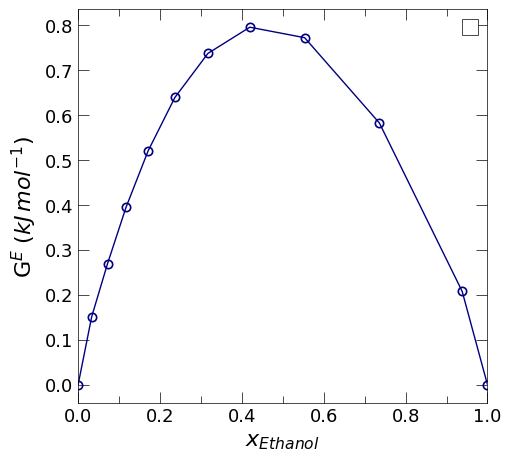

In [104]:
therm_plotter.plot_property("g_ex", units="kJ/mol", ylabel=r"G$^E$", xlim=(0, 1), marker="o", ls="-", lw=1, mew=1.2)

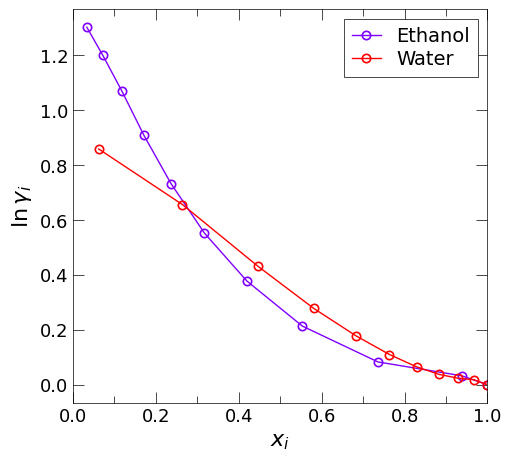

In [105]:
therm_plotter.plot_property(
    "lngamma", ylabel=r"$\ln \gamma_i$", xlim=(0, 1), marker="o", ls="-", lw=1, mew=1.2, cmap="rainbow"
)